In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

sns.set_theme(style="whitegrid")

In [2]:
from pathlib import Path
BASE_DIR = Path.cwd().parent

RAW_DATA = BASE_DIR / "data" / "raw"
PROCESSED_DATA = BASE_DIR / "data" / "processed"

In [3]:
fund_master = pd.read_csv(
    RAW_DATA / "01_fund_master.csv"
)

nav_history = pd.read_csv(
    PROCESSED_DATA / "nav_history_cleaned.csv"
)

scheme_performance = pd.read_csv(
    PROCESSED_DATA / "scheme_performance_cleaned.csv"
)

investor_transactions = pd.read_csv(
    PROCESSED_DATA / "investor_transactions_cleaned.csv"
)

aum_by_fund_house = pd.read_csv(
    RAW_DATA / "03_aum_by_fund_house.csv"
)

monthly_sip_inflows = pd.read_csv(
    RAW_DATA / "04_monthly_sip_inflows.csv"
)

category_inflows = pd.read_csv(
    RAW_DATA / "05_category_inflows.csv"
)

industry_folio_count = pd.read_csv(
    RAW_DATA / "06_industry_folio_count.csv"
)

portfolio_holdings = pd.read_csv(
    RAW_DATA / "09_portfolio_holdings.csv"
)

In [4]:


# Daily returns
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

var_cvar_results = []

for fund in nav_history["amfi_code"].unique():

    returns = (
        nav_history[
            nav_history["amfi_code"] == fund
        ]["daily_return"]
        .dropna()
    )

    var_95 = np.percentile(
        returns,
        5
    )

    cvar_95 = (
        returns[
            returns <= var_95
        ]
        .mean()
    )

    var_cvar_results.append(
        [
            fund,
            var_95,
            cvar_95
        ]
    )

var_cvar_df = pd.DataFrame(
    var_cvar_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

display(var_cvar_df.head())

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


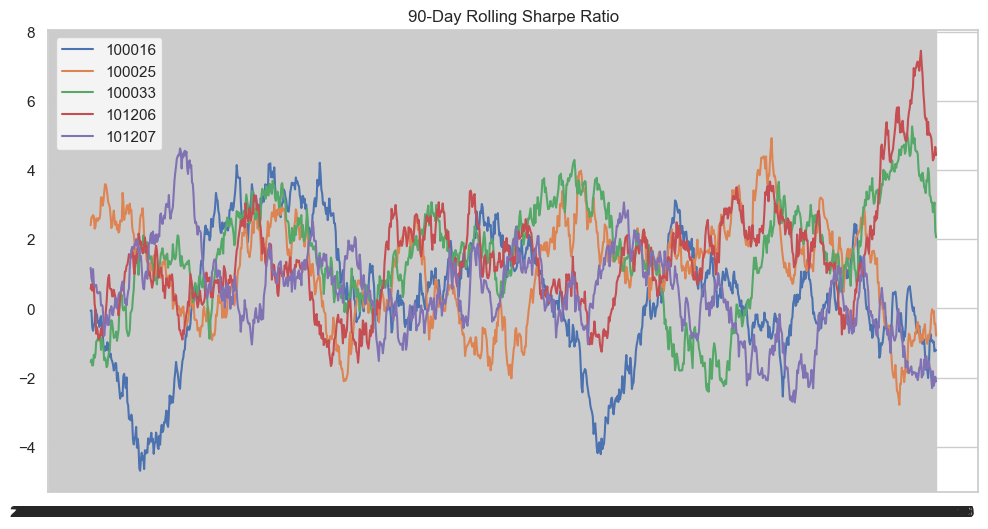

In [5]:
import matplotlib.pyplot as plt
import numpy as np

selected_funds = [
    100016,
    100025,
    100033,
    101206,
    101207
]

plt.figure(figsize=(12,6))

for fund in selected_funds:

    df = (
        nav_history[
            nav_history["amfi_code"] == fund
        ]
        .sort_values("date")
        .copy()
    )

    rolling_sharpe = (
        df["daily_return"]
        .rolling(90)
        .mean()
        /
        df["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.legend()
plt.title("90-Day Rolling Sharpe Ratio")
plt.show()

In [6]:
investor_transactions["transaction_date"] = pd.to_datetime(
    investor_transactions["transaction_date"]
)

cohort = (
    investor_transactions
    .groupby("investor_id")
    ["transaction_date"]
    .min()
    .dt.year
)

investor_transactions["cohort_year"] = (
    investor_transactions["investor_id"]
    .map(cohort)
)

cohort_analysis = (
    investor_transactions
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=(
            "amount_inr",
            "mean"
        ),
        total_invested=(
            "amount_inr",
            "sum"
        )
    )
)

display(cohort_analysis)

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [7]:
top_funds = (
    investor_transactions
    .groupby(
        [
            "cohort_year",
            "amfi_code"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
)

top_fund_per_cohort = (
    top_funds
    .sort_values(
        "count",
        ascending=False
    )
    .groupby("cohort_year")
    .first()
)

display(top_fund_per_cohort)

,amfi_code,count
cohort_year,,
2024,148568,874
2025,119599,12


In [8]:
sip_txn = (
    investor_transactions[
        investor_transactions[
            "transaction_type"
        ] == "SIP"
    ]
    .copy()
)

sip_txn = sip_txn.sort_values(
    [
        "investor_id",
        "transaction_date"
    ]
)

gap_results = []

for investor, df in sip_txn.groupby(
    "investor_id"
):

    if len(df) >= 6:

        avg_gap = (
            df["transaction_date"]
            .diff()
            .dt.days
            .mean()
        )

        gap_results.append(
            [
                investor,
                avg_gap,
                avg_gap > 35
            ]
        )

sip_continuity = pd.DataFrame(
    gap_results,
    columns=[
        "investor_id",
        "avg_gap_days",
        "at_risk"
    ]
)

display(
    sip_continuity.head()
)

,investor_id,avg_gap_days,at_risk
0,INV000004,85.400000,True
1,INV000008,70.400000,True
2,INV000010,64.800000,True
3,INV000011,40.166667,True
4,INV000012,57.000000,True


In [9]:
risk_input = "Moderate"

recommendations = (
    scheme_performance[
        scheme_performance[
            "risk_grade"
        ] == risk_input
    ]
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(3)
)

display(
    recommendations[
        [
            "amfi_code",
            "fund_house",
            "category",
            "sharpe_ratio"
        ]
    ]
)

,amfi_code,fund_house,category,sharpe_ratio
5,100016,HDFC Mutual Fund,Large Cap,1.06
34,148567,Mirae Asset MF,Large Cap,1.06
11,120504,ICICI Prudential MF,Large Cap,1.03


In [10]:
equity_funds = (
    portfolio_holdings
    .groupby(
        [
            "amfi_code",
            "sector"
        ]
    )["weight_pct"]
    .sum()
    .reset_index()
)

hhi_results = []

for fund in equity_funds[
    "amfi_code"
].unique():

    temp = (
        equity_funds[
            equity_funds[
                "amfi_code"
            ] == fund
        ]
    )

    hhi = np.sum(
        (
            temp["weight_pct"]
            / 100
        ) ** 2
    )

    hhi_results.append(
        [fund, hhi]
    )

hhi_df = pd.DataFrame(
    hhi_results,
    columns=[
        "amfi_code",
        "HHI"
    ]
)

display(
    hhi_df.sort_values(
        "HHI",
        ascending=False
    ).head()
)

,amfi_code,HHI
11,119092,0.296769
30,148569,0.254992
27,125498,0.253155
6,102887,0.251383
32,149323,0.241077


In [11]:
var_cvar_df.to_csv(
    "../reports/var_cvar.csv",
    index=False
)

sip_continuity.to_csv(
    "../reports/sip_continuity.csv",
    index=False
)

hhi_df.to_csv(
    "../reports/sector_hhi.csv",
    index=False
)